# Downwinding Workflow Example 1: 
- Rectangular domain no river mask
- Calculating slopes with a downwinding approach to be consistent with ParFlow's OverlandFlow boundary conditon. 

This example walks through the simplest case where
you have a rectangular domain and no river network specified a-priori
in this case the only input required is a DEM

This example usese the test domain from Condon and Maxwell (2019) (https://doi.org/10.1016/j.cageo.2019.01.020)
 the datasets for this domain are provided with the PriorityFlow R package
 to use your own datasets you should have a DEM formatted as a matrix 
 with [i,j] corresponding to the x and y axes of the domain 
(i.e. DEM[0,0] is the lower left corner of the domain and DEM[nx - 1,ny - 1] is the upper right).

In [5]:
import numpy as np

from priority_flow import (
    init_queue,
    d4_traverse_b,
    load_dem,
    drainage_area,
    calc_subbasins,
    slope_calc_upwind,
)

from parflow.tools.io import read_pfb, write_pfb
import matplotlib.pyplot as plt

In [6]:
# -------------------------------------------------------------------------
# Settings 
# -------------------------------------------------------------------------
# DEM processing
ep = 0.01  # epsilon for D4TraverseB (PriorityFlow processing)

# Slope scaling
maxslope = 0.5  # maximum slope; set to -1 to disable
minslope = 1e-5  # minimum slope; set to -1 to disable
scale = 0.1  # max ratio of |secondary| / |primary| (secondaryTH)

# River and subbasin size for slope calculations
sub_th = 100  # area threshold (cells) for subbasin delineation
riv_th = sub_th  # optional: threshold for river mask for slope processing
riv_method = 3  # 0: none, 1: scale river secondary, 2: basin mean, 3: reach mean
mrg_th = 10  # merge threshold for small subbasins

# Grid dimensions for slopes
dx = 1000.0
dy = 1000.0

# Run name for outputs
runname = "Test"

# -------------------------------------------------------------------------
# Load DEM and basic info
# -------------------------------------------------------------------------
DEM = load_dem().T
nx, ny = DEM.shape
print(f"Domain size: nx={nx}, ny={ny}")

Domain size: nx=172, ny=215


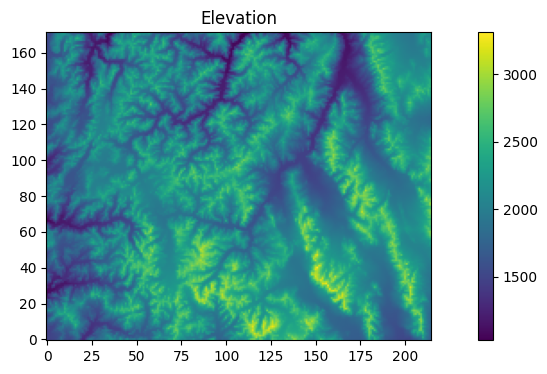

In [10]:
# Plotting
fig, axes = plt.subplots(1, 1, figsize=(12, 4))
im0 = axes.imshow(DEM, cmap='viridis', origin="lower")
axes.set_title("Elevation")
plt.colorbar(im0, ax=axes)

## Process the DEM
1. initialize the queue with all the rectangular border cells
2. Process the DEM so that all cells drain to the boundaries

In [11]:
init = init_queue(DEM)

No init mask provided all border cells will be added to queue
No domain mask provided using entire domain
No border provided, setting border using domain mask


In [20]:
trav_hs = d4_traverse_b(
    DEM,
    init["queue"].copy(),
    init["marked"].copy(),
    basins=init["basins"].copy(),
    epsilon=ep,
)
print("DEM processing complete.")

DEM processing complete.


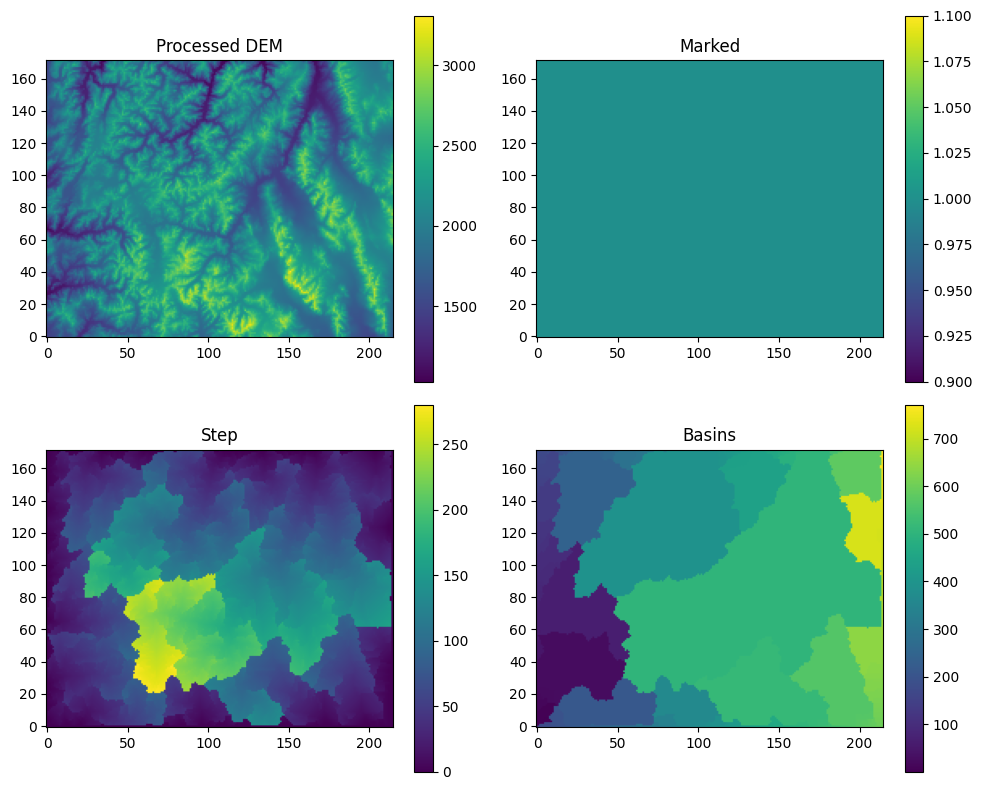

In [21]:
def _plot_trav_hs(trav_hs):
    """Plot DEM processing results."""
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    im0 = axes[0, 0].imshow(trav_hs["dem"], cmap='viridis', origin='lower')
    axes[0, 0].set_title("Processed DEM")
    plt.colorbar(im0, ax=axes[0, 0])
    im1 = axes[0, 1].imshow(trav_hs["marked"], cmap='viridis', origin='lower')
    axes[0, 1].set_title("Marked")
    plt.colorbar(im1, ax=axes[0, 1])
    im2 = axes[1, 0].imshow(trav_hs["step"], cmap='viridis', origin='lower')
    axes[1, 0].set_title("Step")
    plt.colorbar(im2, ax=axes[1, 0])
    im3 = axes[1, 1].imshow(trav_hs["basins"], cmap='viridis', origin='lower')
    axes[1, 1].set_title("Basins")
    plt.colorbar(im3, ax=axes[1, 1])
    plt.tight_layout()
    plt.savefig("trav_hs.png", dpi=150)
    plt.show()
    plt.close()

_plot_trav_hs(trav_hs)

Calculate the slopes
Note this step also fixes the directions of the borders because
directions are not provided when the queue is initialized

## Option 1: just calcualte the slopes for the entire domain with no distinction between river and hillslope cells
In this example secondary slope scaling is turned on and the secondary
Slopes in the secondary direction are set to a maximum of 0.1*primary flow direction
To calculate only slopes in the primary flow direction set the secondaryTH to 0
Additionally primary slopes are limited by min slope and max slope thresholds

In [23]:
slopes_uw = slope_calc_upwind(
    dem=trav_hs["dem"].copy(),
    direction=trav_hs["direction"].copy(),
    dx=dx,
    dy=dy,
    minslope=minslope,
    maxslope=maxslope,
    secondary_th=scale,
)

No mask provided, initializing mask for complete domain
upwinding slopes
Limiting slopes to maximum absolute value of 0.5
Limiting the ratio of secondary to primary slopes 0.1
After processing: 0 Flat cells left
Limiting slopes to minimum 1e-05


## Option 2: If you would like to handle river cells differently from the rest of the domain

Calculate the drainage area

In [24]:
area = drainage_area(trav_hs["direction"], printflag=False)

In [33]:
subbasin = calc_subbasins(
    trav_hs["direction"].copy(),
    area=area,
    mask=None,
    riv_th=sub_th,
    merge_th=mrg_th,
)

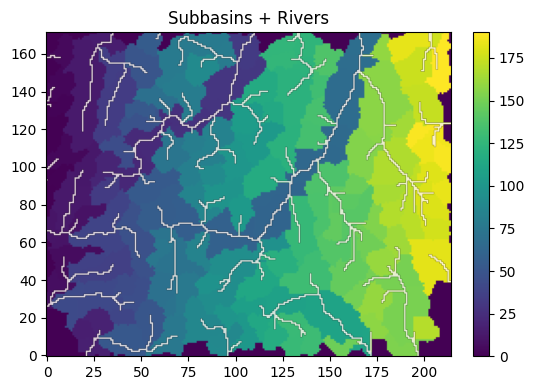

In [36]:
temp = subbasin['RiverMask'].copy()
temp[temp == 0] = np.nan

fig, ax = plt.subplots(figsize=(6, 4))
# Base layer
im0 = ax.imshow(subbasin['subbasins'],
                cmap='viridis',
                origin='lower')
# Overlay (rivers)
im1 = ax.imshow(temp * 2,
                cmap='Reds',      # different colormap helps visibility
                origin='lower',
                alpha=0.8)        # transparency like add=TRUE overlay
ax.set_title("Subbasins + Rivers")
plt.colorbar(im0, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

### Calculate the slopes

The "river_method' flag here determines how the river cells will be handeled (e.g. using subbasin averages along reaches). Refer to the top of this script or the function for details.

In [38]:
slopes_uw = slope_calc_upwind(
    dem=trav_hs["dem"].copy(),
    direction=trav_hs["direction"].copy(),
    dx=dx,
    dy=dy,
    minslope=minslope,
    maxslope=maxslope,
    secondary_th=scale,
    river_method=riv_method,
    rivermask=subbasin["RiverMask"].copy(),
    subbasins=subbasin["subbasins"].copy(),
)

No mask provided, initializing mask for complete domain
upwinding slopes
Limiting slopes to maximum absolute value of 0.5
Limiting the ratio of secondary to primary slopes 0.1
River Method 3: assigning average river slope to river cells by watershed
Scaling secondary slopes along river mask to 0 * primary slope
After processing: 0 Flat cells left
Limiting slopes to minimum 1e-05


## Option 2b

Alternate more advanced approach: Define a river mask separate from the subbasin river mask and use this for the slope calculations. If you do this the average slopes will still be calculated
by subbasin using the sub_th, but you can apply those average sloeps to more river cells by setting a lower threshold here. This is the 'riv_th' set at the top
if you set riv_th=sub_th at the top this will have the same effect as just running the slope calc with the subbasin$RiverMask

In [39]:
rivers = np.zeros_like(area)
rivers[area < riv_th] = 0
rivers[area >= riv_th] = 1

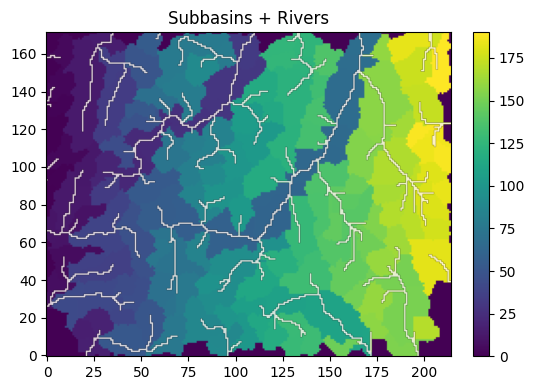

In [40]:
temp = rivers.copy()
temp[temp == 0] = np.nan

fig, ax = plt.subplots(figsize=(6, 4))
# Base layer
im0 = ax.imshow(subbasin['subbasins'],
                cmap='viridis',
                origin='lower')
# Overlay (rivers)
im1 = ax.imshow(temp * 2,
                cmap='Reds',      # different colormap helps visibility
                origin='lower',
                alpha=0.8)        # transparency like add=TRUE overlay
ax.set_title("Subbasins + Rivers")
plt.colorbar(im0, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

In [41]:
# Upwind slopes using alternate river mask but same subbasins
slopes_uw = slope_calc_upwind(
    dem=trav_hs["dem"].copy(),
    direction=trav_hs["direction"].copy(),
    dx=dx,
    dy=dy,
    minslope=minslope,
    maxslope=maxslope,
    secondary_th=scale,
    river_method=riv_method,
    rivermask=rivers,
    subbasins=subbasin["subbasins"].copy(),
)

No mask provided, initializing mask for complete domain
upwinding slopes
Limiting slopes to maximum absolute value of 0.5
Limiting the ratio of secondary to primary slopes 0.1
River Method 3: assigning average river slope to river cells by watershed
Scaling secondary slopes along river mask to 0 * primary slope
After processing: 0 Flat cells left
Limiting slopes to minimum 1e-05


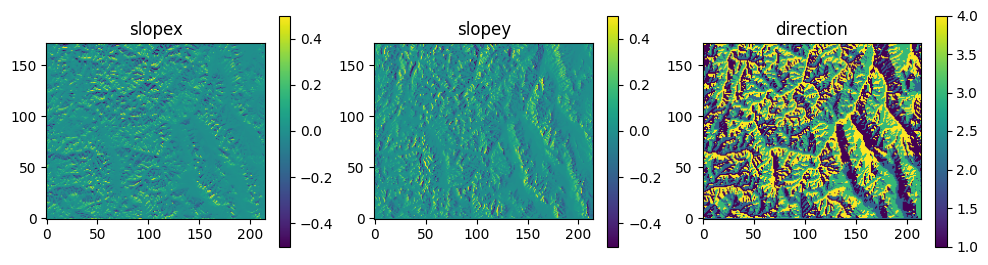

In [50]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
im0 = axes[0].imshow(slopes_uw['slopex'], cmap='viridis', origin='lower')
axes[0].set_title("slopex")
plt.colorbar(im0, ax=axes[0])
im1 = axes[1].imshow(slopes_uw['slopey'], cmap='viridis', origin='lower')
axes[1].set_title("slopey")
plt.colorbar(im1, ax=axes[1])
im2 = axes[2].imshow(slopes_uw['direction'], cmap='viridis', origin='lower')
axes[2].set_title("direction")
plt.colorbar(im2, ax=axes[2])
plt.show()

In [51]:
# Calculate the drainage area - if you went with option 1 for slopes and you didn't do this already
area = drainage_area(slopes_uw["direction"], printflag=False)

In [53]:
# Save slope data as PFB files:
write_pfb("slopex.pfb", slopes_uw["slopex"])
write_pfb("slopey.pfb", slopes_uw["slopey"])